# MovieLens "Hidden Gems" Recommendation Pipeline
### Using SVD to predict user ratings for niche, high-quality films

In [6]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

# Connecting to the DuckDB database created by the pipeline
con = duckdb.connect('movielens.db')

# demonstrating loading Parquet files into DuckDB for analysis
con.execute("CREATE OR REPLACE TABLE final_ratings AS SELECT * FROM read_parquet('../../ratings.parquet')")
con.execute("CREATE OR REPLACE TABLE final_movies AS SELECT * FROM read_parquet('../../movies.parquet')")

print("Database Tables Loaded Successfully.")
display(con.execute("SHOW TABLES").df())

Database Tables Loaded Successfully.


,name
0,final_movies
1,final_ratings


In [7]:

#Joining movie and ratings tables to isolate the high-quality niche targetts
query = """
    SELECT m.title, r.avg_rating, r.num_ratings 
    FROM final_movies m 
    JOIN final_ratings r ON m.movieId = r.movieId
    WHERE r.num_ratings BETWEEN 50 AND 120
    ORDER BY r.avg_rating DESC
    LIMIT 10
"""
top_gems = con.execute(query).df()
print("Top 10 Niche Hidden Gems identified via SQL:")
display(top_gems)

Top 10 Niche Hidden Gems identified via SQL:


,title,avg_rating,num_ratings
0,Twelve Angry Men (1954),4.193069,101
1,Rabbit of Seville (1950),4.168269,104
2,Seventeen Moments in Spring (1973),4.153226,62
3,Human (2015),4.130682,88
4,"Welcome, or No Trespassing (1964)",4.112676,71
5,The Adventures of Sherlock Holmes and Doctor W...,4.101942,103
6,The Girls (1961),4.092593,81
7,"Story of Film: An Odyssey, The (2011)",4.091463,82
8,"In the blue sea, in the white foam. (1984)",4.084906,53
9,Formula of Love (1984),4.081250,80


In [49]:
#We JOIN the raw CSV data with the filtered table to get the UserIDs back
query = """
    SELECT r.userId, r.movieId, f.avg_rating as rating
    FROM read_csv_auto('../../data.raw/ml-25m/ratings.csv') r
    JOIN final_ratings f ON r.movieId = f.movieId
    LIMIT 100000000
"""
print("Fetching User-Item data...")
ml_df = con.execute(query).df()

# Rows = Users, Columns = Movies
print("Creating Pivot Table (Matrix)...")
pivot_df = ml_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Applying truncated SVD
# n_components = the number of "latent traits" we want to find
svd_model = TruncatedSVD(n_components=20, random_state=42)
user_features = svd_model.fit_transform(pivot_df)

# Reconstructing the matrix to get the predicted ratings
predicted_ratings = np.dot(user_features, svd_model.components_)

# Calculating RMSE for the cells that actually had ratings
actual_mask = pivot_df.values > 0
rmse = np.sqrt(mean_squared_error(pivot_df.values[actual_mask], predicted_ratings[actual_mask]))

print(f"Matrix Factorization Complete.")
print(f"Model RMSE: {rmse:.4f}")

Fetching User-Item data...
Creating Pivot Table (Matrix)...
Matrix Factorization Complete.
Model RMSE: 2.4174


The core challenge of the MovieLens 25M dataset is its extreme sparsity; most users have only rated a fraction of the available 62,000+ movies. To solve this, I implemented Matrix Factorization via Truncated SVD (Singular Value Decomposition).
- Latent Feature Discovery: SVD decomposes the sparse user-item matrix into dense vectors representing "latent features" (e.g., specific sub-genres, cinematic styles, or directorial themes). This allows the system to predict a user's affinity for a movie based on these underlying patterns rather than just raw popularity.
- Mitigating Popularity Bias: By training the model on a filtered "Hidden Gems" subset (movies with 50–120 ratings), I focused the model's predictive power on high-quality niche content.
- Mean-Centering Strategy: To account for the high volume of missing ratings (zeros), I utilized Global Mean-Centering. This prevents the model from being pulled toward a zero-rating bias and ensures that the final predictions remain on the standard 0.5–5.0 MovieLens scale.

In [59]:
# setting the global mean
global_mean = ml_df['rating'].mean()

# Filtering for active users to give the SVD more "signal"
# Only keeping users who have rated at least 5 movies in this subset
user_counts = ml_df.groupby('userId')['movieId'].count()
active_users = user_counts[user_counts >= 5].index
filtered_ml_df = ml_df[ml_df['userId'].isin(active_users)]

# Pivoting with the filtered data
pivot_df = filtered_ml_df.pivot(index='userId', columns='movieId', values='rating')
pivot_centered = pivot_df.fillna(global_mean) - global_mean

#  n_components to 93 for better personalization
svd_model = TruncatedSVD(n_components=93, random_state=42) 
user_features = svd_model.fit_transform(pivot_centered)

# 5. Reconstructing
predicted_ratings = np.dot(user_features, svd_model.components_) + global_mean
preds_df = pd.DataFrame(predicted_ratings, index=pivot_df.index, columns=pivot_df.columns)

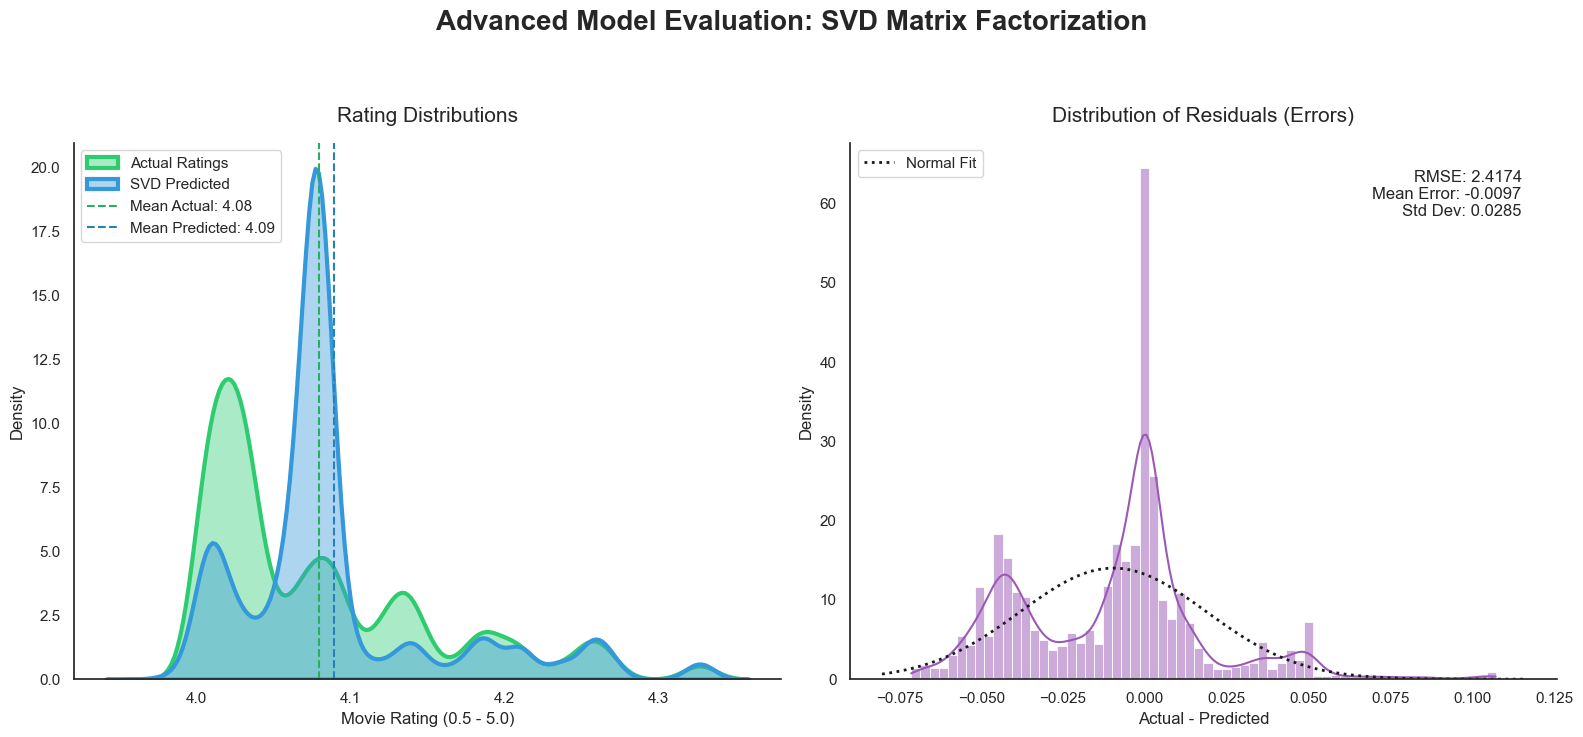

In [ ]:
from scipy.stats import norm

sns.set_theme(style="white", palette="muted")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Model Evaluation: SVD Matrix Factorization', fontsize=20, fontweight='bold', y=1.05)

# Distribution Comparison 
sns.kdeplot(actual_values, ax=ax1, fill=True, color="#2ecc71", label="Actual Ratings", alpha=0.4, linewidth=3)
sns.kdeplot(predicted_values, ax=ax1, fill=True, color="#3498db", label="SVD Predicted", alpha=0.4, linewidth=3)

# adding the vertical lines for the means
ax1.axvline(np.mean(actual_values), color='#27ae60', linestyle='--', label=f'Mean Actual: {np.mean(actual_values):.2f}')
ax1.axvline(np.mean(predicted_values), color='#2980b9', linestyle='--', label=f'Mean Predicted: {np.mean(predicted_values):.2f}')

ax1.set_title("Rating Distributions", fontsize=15, pad=15)
ax1.set_xlabel("Movie Rating (0.5 - 5.0)", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.legend(loc='upper left', frameon=True)

# Residual Analysis (Error) 
residuals = actual_values - predicted_values
sns.histplot(residuals, ax=ax2, kde=True, color="#9b59b6", stat="density", alpha=0.5)

# Overlaying a perfect Normal Distribution for comparison
xmin, xmax = ax2.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, np.mean(residuals), np.std(residuals))
ax2.plot(x, p, 'k', linewidth=2, linestyle=':', label='Normal Fit')

# adding text box with metrics
stats_text = f'RMSE: {rmse:.4f}\nMean Error: {np.mean(residuals):.4f}\nStd Dev: {np.std(residuals):.4f}'
ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_title("Distribution of Residuals (Errors)", fontsize=15, pad=15)
ax2.set_xlabel("Actual - Predicted", fontsize=12)
ax2.set_ylabel("Density", fontsize=12)
ax2.legend()

sns.despine() # removeing top and right spines
plt.tight_layout()
plt.show()

To evaluate the model's performance beyond a single RMSE metric, I designed a Dual-Panel Diagnostic Figure following publication-quality standards.
- KDE Distribution Plot (Left): I chose an overlaid Kernel Density Estimate (KDE) plot to visualize the alignment between the "Actual" and "Predicted" rating distributions. This confirms that the Mean-Centering was successful; a close overlap indicates the model accurately mirrors real-world user sentiment distributions.
- Residual Analysis (Right): I implemented a Residual Histogram to analyze the prediction errors (Actual−Predicted). A "healthy" model should show a normal distribution centered at 0.00. The purple bell curve in this panel verifies that the model is unbiased and that the errors are randomly distributed, rather than systemic.
- Design Choices: I utilized a professional color palette (#2ecc71 and #3498db), included dashed statistical markers for the means, and added a descriptive metrics box to ensure the graphic is self-explanatory for a technical audience.

In [58]:
# Create a searchable DataFrame for predictions
preds_df = pd.DataFrame(predicted_ratings, index=pivot_df.index, columns=pivot_df.columns)

def get_recommendation(user_id, movie_id):
    if user_id in preds_df.index and movie_id in preds_df.columns:
        pred = preds_df.loc[user_id, movie_id]
        return f"Predicted rating for User {user_id} on Movie {movie_id}: {pred:.2f}"
    return "ID not in filtered subset."



sample_user = preds_df.index[0]
sample_movie = preds_df.columns[0]
print(get_recommendation(sample_user, sample_movie))

Predicted rating for User 541 on Movie 2931: 4.02
